# Rental Price Prediction

**Goal:** guess the monthly rent (`price`) of an apartment from its size, rooms, and location.

**Score:** RMSE, the typical size of our miss in dollars. Lower is better.

**Plan**
1. Load and look at the data
2. Clean it
3. Set up a fair way to test models
4. Compare five models
5. Add new features and predict log rent
6. Tune the best models
7. Run a tougher test
8. Pick the final model and write `predictions.csv`

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.1f}".format)

## 2. Load the data

Both CSV files sit in the same folder as this notebook.

In [2]:
train_df = pd.read_csv("challenge1_train.csv")
test_df = pd.read_csv("challenge1_test.csv")

print("Train rows and columns:", train_df.shape)
print("Test rows and columns: ", test_df.shape)
train_df.head()

Train rows and columns: (7398, 10)
Test rows and columns:  (2467, 9)


,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6,-122.3,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.8,-74.0,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.8,-122.4,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.1,-77.1,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.1,-77.0,housing/rent/apartment,Thumbnail,NC


## 3. Look at the data

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           7398 non-null   int64  
 1   price        7398 non-null   int64  
 2   bathrooms    7398 non-null   float64
 3   bedrooms     7398 non-null   int64  
 4   square_feet  7398 non-null   int64  
 5   latitude     7398 non-null   float64
 6   longitude    7398 non-null   float64
 7   category     7398 non-null   str    
 8   has_photo    7398 non-null   str    
 9   state        7398 non-null   str    
dtypes: float64(3), int64(4), str(3)
memory usage: 578.1 KB


In [4]:
print("Missing values in train:", int(train_df.isna().sum().sum()))
print("Missing values in test: ", int(test_df.isna().sum().sum()))
train_df.describe()

Missing values in train: 0
Missing values in test:  0


,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude
count,"7,398.0","7,398.0","7,398.0","7,398.0","7,398.0","7,398.0","7,398.0"
mean,"4,954.1","1,462.8",1.4,1.7,940.9,37.6,-94.4
std,"2,845.3",821.6,0.6,0.9,502.2,5.5,15.7
min,2.0,200.0,1.0,0.0,116.0,21.3,-158.0
25%,"2,495.2",949.0,1.0,1.0,650.0,33.6,-98.5
50%,"4,972.5","1,273.5",1.0,2.0,807.5,38.8,-93.7
75%,"7,435.8","1,695.0",2.0,2.0,"1,100.0",41.3,-81.6
max,"9,863.0","8,800.0",7.0,9.0,"5,921.0",61.6,-70.3


In [5]:
for col in ["category", "has_photo", "state"]:
    print(f"{col}: {train_df[col].nunique()} different values")
    print(train_df[col].value_counts().head(5).to_string(), "\n")

print("States in test but not in train:", set(test_df["state"]) - set(train_df["state"]))

category: 3 different values
category
housing/rent/apartment     7395
housing/rent/home             2
housing/rent/short_term       1 

has_photo: 3 different values
has_photo
Thumbnail    6566
Yes           693
No            139 

state: 50 different values
state
TX    1327
CA     688
WA     375
MD     341
NC     340 

States in test but not in train: {'WY'}


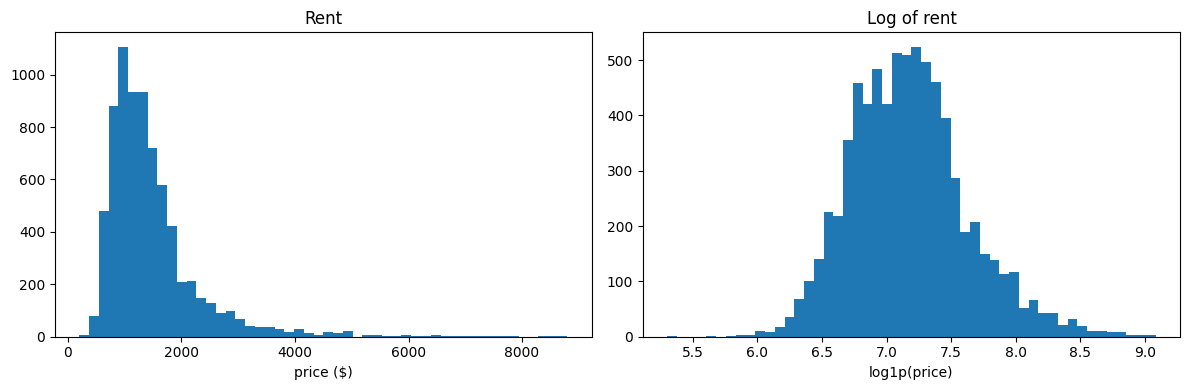

Skew of rent:        2.71
Skew of log of rent: 0.54


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["price"], bins=50)
axes[0].set_title("Rent")
axes[0].set_xlabel("price ($)")
axes[1].hist(np.log1p(train_df["price"]), bins=50)
axes[1].set_title("Log of rent")
axes[1].set_xlabel("log1p(price)")
plt.tight_layout()
plt.show()

print("Skew of rent:       ", round(train_df["price"].skew(), 2))
print("Skew of log of rent:", round(np.log1p(train_df["price"]).skew(), 2))

In [7]:
dup_rows = train_df.drop(columns="ID").duplicated().sum()
location = train_df["latitude"].round(3).astype(str) + "_" + train_df["longitude"].round(3).astype(str)
test_location = test_df["latitude"].round(3).astype(str) + "_" + test_df["longitude"].round(3).astype(str)

print("Rows that are exact copies (same price too):", dup_rows)
print("Different map locations in train:", location.nunique(), "out of", len(train_df), "rows")
print(f"Test rows at a location we also see in train: {test_location.isin(set(location)).mean():.0%}")
print("Listings under 200 sq ft:", (train_df["square_feet"] < 200).sum())

Rows that are exact copies (same price too): 111
Different map locations in train: 2033 out of 7398 rows
Test rows at a location we also see in train: 84%
Listings under 200 sq ft: 3


### What we noticed

- **No missing values** in either file, so no filling in is needed.
- **Rent is lopsided.** Most units rent for $900 to $1,700, but a few go up to $8,800. Taking the log makes it much more even (skew drops from 2.7 to 0.5), so we test predicting log rent later.
- **`category` is almost useless.** 7,395 of 7,398 rows are apartments.
- **`has_photo`** has 3 values and **`state`** has 50. Texas has the most listings by far.
- **Wyoming shows up in test but never in train.** The model will treat it as "unknown state" and lean on latitude and longitude instead.
- **111 rows are exact copies** of other rows, price included. We remove them next.
- **Many listings share a map point.** Only about 2,000 different locations across 7,398 rows, and 84% of test rows sit at a location that also appears in train. This matters for how we test (see section 11).

## 4. Clean the data

We remove rows that are exact copies of another row, price included. Copies add nothing new and can make test scores look better than they are, because the same row can land in both the training and the checking part of a split.

We keep the few very small listings (under 200 sq ft). Removing them made the score slightly worse, and they may be real studios or rooms.

In [8]:
before = len(train_df)
train_df = train_df.drop_duplicates(subset=train_df.columns.drop("ID")).reset_index(drop=True)
print(f"Removed {before - len(train_df)} copied rows. {len(train_df)} rows left.")

Removed 111 copied rows. 7287 rows left.


## 5. Split into inputs and target

`ID` is just a row number, so we never use it to predict.

In [9]:
X_raw = train_df.drop(columns=["price", "ID"])
y = train_df["price"]

test_ids = test_df["ID"]
X_test_raw = test_df.drop(columns=["ID"])

def column_types(X):
    numeric = X.select_dtypes(include="number").columns.tolist()
    text = X.select_dtypes(exclude="number").columns.tolist()
    return numeric, text

numeric_cols, categorical_cols = column_types(X_raw)
print("Number columns:", numeric_cols)
print("Text columns:  ", categorical_cols)

Number columns: ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
Text columns:   ['category', 'has_photo', 'state']


## 6. How we test models

Every model is tested the same way so the scores are fair to compare.

- **5-fold cross validation (CV).** We cut the training data into 5 parts. Each part takes a turn as the "test", and the model learns from the other 4. The average miss across the 5 turns is the main score.
- **One 80/20 split.** We train on 80% and check on 20%. Comparing the miss on data the model has seen (train) with data it has not seen (val) shows if a model is memorizing instead of learning.

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 7. Build the model pipeline

One function builds every model the same way:

- number columns get scaled to a similar range (helps Linear Regression, does not hurt the others)
- text columns get turned into 0/1 columns
- optionally, the model learns the **log of rent** and we turn its guess back into dollars at the end

In [11]:
def make_pipeline(model, numeric_cols, categorical_cols, log_target=False):
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ])
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    if log_target:
        pipe = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe


def evaluate(name, pipe, X, y):
    cv_scores = -cross_val_score(pipe, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    pipe.fit(X_tr, y_tr)
    train_rmse = rmse(y_tr, pipe.predict(X_tr))
    val_rmse = rmse(y_val, pipe.predict(X_val))
    return {
        "Model": name,
        "CV RMSE": cv_scores.mean(),
        "CV spread": cv_scores.std(),
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Gap": val_rmse - train_rmse,
    }

## 8. Compare five models on the original columns

The four required models, plus **HistGradientBoosting**, a faster version of gradient boosting built into scikit-learn.

In [12]:
def fresh_models():
    return {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    }

base_results = pd.DataFrame([
    evaluate(name, make_pipeline(model, numeric_cols, categorical_cols), X_raw, y)
    for name, model in fresh_models().items()
]).sort_values("CV RMSE").reset_index(drop=True)
base_results

,Model,CV RMSE,CV spread,Train RMSE,Val RMSE,Gap
0,Hist Gradient Boosting,408.9,8.7,318.9,416.4,97.6
1,Random Forest,423.0,12.6,160.4,426.1,265.7
2,Gradient Boosting,458.3,14.7,405.2,482.5,77.3
3,Linear Regression,529.8,10.7,518.8,544.6,25.8
4,Decision Tree,569.7,24.8,43.5,534.7,491.2


### What this shows

- **Best:** Hist Gradient Boosting (about $409 average miss), then Random Forest ($423).
- **Memorizing:** the Decision Tree is almost perfect on data it has seen ($44) but misses by $535 on new data. That huge gap means it memorized the training rows. Random Forest shows the same problem, but less.
- **Too simple:** Linear Regression misses by about $520 to $545 on both seen and new data. The small gap means it is not memorizing, it just cannot capture how location and size really affect rent.
- The two boosting models sit in between, with the most balanced results.

## 9. New features and log rent

New columns, built only from the inputs (never from the price):

| Feature | What it means | Why it may help |
|---|---|---|
| `sqft_per_room` | space divided by (bedrooms + bathrooms + 1) | roomy vs cramped units |
| `log_sqft` | log of square feet | shrinks the effect of a few huge units |
| `rot45_x`, `rot45_y` | latitude plus and minus longitude | lets tree models draw diagonal lines on the map, not only north/south and east/west |
| `category` | merged into "apartment" or "other" | only 3 of 7,000+ rows are not apartments |

We also try predicting the **log of rent**, since rent is lopsided (a few very expensive units).

In [13]:
def add_features(df):
    df = df.copy()
    df["sqft_per_room"] = df["square_feet"] / (df["bedrooms"] + df["bathrooms"] + 1)
    df["log_sqft"] = np.log1p(df["square_feet"])
    df["rot45_x"] = df["latitude"] + df["longitude"]
    df["rot45_y"] = df["latitude"] - df["longitude"]
    df["category"] = df["category"].where(df["category"] == "housing/rent/apartment", "other")
    return df

X = add_features(X_raw)
X_test_final = add_features(X_test_raw)
fe_numeric, fe_categorical = column_types(X)

In [14]:
fe_rows = []
for name, model in fresh_models().items():
    if name in ("Linear Regression", "Decision Tree"):
        continue
    fe_rows.append(evaluate(f"{name} + features", make_pipeline(model, fe_numeric, fe_categorical), X, y))
    model = fresh_models()[name]
    fe_rows.append(evaluate(f"{name} + features + log rent", make_pipeline(model, fe_numeric, fe_categorical, log_target=True), X, y))

fe_results = pd.DataFrame(fe_rows).sort_values("CV RMSE").reset_index(drop=True)
fe_results

,Model,CV RMSE,CV spread,Train RMSE,Val RMSE,Gap
0,Hist Gradient Boosting + features + log rent,399.0,13.5,319.3,417.4,98.1
1,Hist Gradient Boosting + features,402.3,7.7,294.7,407.7,113.0
2,Random Forest + features + log rent,411.3,11.2,170.9,423.6,252.7
3,Random Forest + features,416.3,9.9,158.5,420.3,261.8
4,Gradient Boosting + features,448.0,13.6,388.3,472.6,84.3
5,Gradient Boosting + features + log rent,456.5,18.3,415.2,488.1,72.9


### What this shows

- The new features plus log rent helped the tree forests: Hist Gradient Boosting improved from $409 to $399, and Random Forest from $423 to $411.
- Log rent on its own is not a sure win. It helped Hist Gradient Boosting and Random Forest a little, but made plain Gradient Boosting worse ($448 to $457) with its default settings. So we still test it, model by model, instead of assuming it helps.

## 10. Tune the settings (grid search)

We try every mix of a few settings and keep the mix with the best CV score. All three searches use the new features, log rent, and the same 5 folds.

In [15]:
def grid(model, params):
    pipe = make_pipeline(model, fe_numeric, fe_categorical, log_target=True)
    params = {f"regressor__model__{k}": v for k, v in params.items()}
    search = GridSearchCV(pipe, params, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    search.fit(X, y)
    return search

rf_grid = grid(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), {
    "n_estimators": [200],
    "min_samples_leaf": [1, 3],
    "max_features": [0.5, 1.0],
})
gb_grid = grid(GradientBoostingRegressor(random_state=RANDOM_STATE), {
    "n_estimators": [300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
})
hgb_grid = grid(HistGradientBoostingRegressor(random_state=RANDOM_STATE), {
    "max_iter": [600],
    "learning_rate": [0.05, 0.1],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [5, 20],
})

def short(params):
    return {k.split("__")[-1]: v for k, v in params.items()}

tuned = pd.DataFrame([
    {"Model": "Random Forest (tuned)", "CV RMSE": -rf_grid.best_score_, "Best settings": short(rf_grid.best_params_)},
    {"Model": "Gradient Boosting (tuned)", "CV RMSE": -gb_grid.best_score_, "Best settings": short(gb_grid.best_params_)},
    {"Model": "Hist Gradient Boosting (tuned)", "CV RMSE": -hgb_grid.best_score_, "Best settings": short(hgb_grid.best_params_)},
]).sort_values("CV RMSE").reset_index(drop=True)
pd.set_option("display.max_colwidth", None)
tuned

,Model,CV RMSE,Best settings
0,Gradient Boosting (tuned),383.8,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}"
1,Hist Gradient Boosting (tuned),384.4,"{'learning_rate': 0.1, 'max_iter': 600, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}"
2,Random Forest (tuned),408.8,"{'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}"


In [16]:
summary = pd.concat([
    base_results[["Model", "CV RMSE"]].assign(Setup="original columns"),
    fe_results[["Model", "CV RMSE"]].assign(Setup="new features"),
    tuned[["Model", "CV RMSE"]].assign(Setup="tuned"),
]).sort_values("CV RMSE").reset_index(drop=True)
summary.head(10)

,Model,CV RMSE,Setup
0,Gradient Boosting (tuned),383.8,tuned
1,Hist Gradient Boosting (tuned),384.4,tuned
2,Hist Gradient Boosting + features + log rent,399.0,new features
3,Hist Gradient Boosting + features,402.3,new features
4,Random Forest (tuned),408.8,tuned
5,Hist Gradient Boosting,408.9,original columns
6,Random Forest + features + log rent,411.3,new features
7,Random Forest + features,416.3,new features
8,Random Forest,423.0,original columns
9,Gradient Boosting + features,448.0,new features


### What this shows

- Tuning made the biggest single jump. Both boosting models land at about **$384**, down from $409 at the start, roughly a 6% smaller miss.
- Gradient Boosting and Hist Gradient Boosting are basically tied (less than $1 apart, well inside the normal fold to fold spread of about $10 to $15).
- Tuned Random Forest stays behind at $409.

## 11. A tougher test: unseen locations

Many listings share the exact same map point. With normal folds, a model can "cheat" a little by seeing the same building in training. Here we keep each location entirely in one fold, so the model is always judged on places it has never seen.

In [17]:
groups = X["latitude"].round(3).astype(str) + "_" + X["longitude"].round(3).astype(str)
tough_cv = GroupKFold(n_splits=5)

tough = []
for name, search in [("Gradient Boosting (tuned)", gb_grid), ("Hist Gradient Boosting (tuned)", hgb_grid)]:
    scores = -cross_val_score(search.best_estimator_, X, y, groups=groups, cv=tough_cv,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    tough.append({"Model": name, "Normal CV RMSE": -search.best_score_,
                  "Unseen-location RMSE": scores.mean(), "Spread": scores.std()})
pd.DataFrame(tough)

,Model,Normal CV RMSE,Unseen-location RMSE,Spread
0,Gradient Boosting (tuned),383.8,474.7,70.4
1,Hist Gradient Boosting (tuned),384.4,460.8,63.8


### What this shows

- When the model has to guess rent at locations it has never seen, the miss grows from about $384 to about $460 to $475, and it swings more from fold to fold.
- Since 84% of the real test rows are at locations we have seen, the normal score is the better guess for the real test. The tough score tells us how the model would do in a brand new neighborhood.
- **Hist Gradient Boosting holds up better here** ($461 vs $475), which suggests it relies less on memorizing specific buildings.

## 12. Final choice

We pick **tuned Hist Gradient Boosting** with the new features and log rent.

- **Accuracy:** tied for best on normal CV (about $384), and best on the tougher unseen-location test.
- **Memorizing:** its gap between seen and new data is moderate, far smaller than the Decision Tree or Random Forest.
- **Complexity:** it is a boosting model, so more complex than one tree or a straight line. The tuning actually picked a simpler setup (small trees of 15 leaves, at least 20 rows per leaf).
- **Speed:** it trains in a few seconds, much faster than regular Gradient Boosting, which matters when we tune or rerun often.
- **Easy to explain:** harder to read than Linear Regression. If we need to explain it, we can show which features matter most using permutation importance.

In [18]:
FINAL_PIPELINE = hgb_grid.best_estimator_

## 13. Train on all the data and write predictions

`GridSearchCV` already retrained the best model on all training rows. We call `.fit` again anyway so this cell works for any model picked above.

In [19]:
FINAL_PIPELINE.fit(X, y)
test_predictions = FINAL_PIPELINE.predict(X_test_final)

predictions_df = pd.DataFrame({"ID": test_ids, "price": test_predictions})
predictions_df.to_csv("predictions.csv", index=False)

print("Rows written:", len(predictions_df))
print("Any missing:", predictions_df["price"].isna().any())
print("Smallest and largest guess:", round(predictions_df["price"].min()), round(predictions_df["price"].max()))
predictions_df.head()

Rows written: 2467
Any missing: False
Smallest and largest guess: 523 9389


,ID,price
0,1,"1,158.2"
1,4,"1,698.2"
2,9,"1,017.5"
3,11,695.6
4,13,655.8


## 14. Ideas for next time

- Tried and dropped: a "neighbor rent" column (average rent of the nearest listings). It did not beat the model above, likely because the trees already learn location from latitude and longitude.
- Try LightGBM or XGBoost and compare with Hist Gradient Boosting.
- Average the guesses of the two or three best models.
- Look at the listings with the biggest misses to find patterns (city, size, very high rent).